In [1]:
!pip install lifelines

  Using cached lifelines-0.30.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached autograd-1.8.0-py3-none-any.whl.metadata (7.5 kB)
  Using cached autograd_gamma-0.5.0-py3-none-any.whl
  Using cached interface_meta-2.0.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached narwhals-2.22.0-py3-none-any.whl.metadata (15 kB)
Using cached lifelines-0.30.3-py3-none-any.whl (409 kB)
Using cached autograd-1.8.0-py3-none-any.whl (51 kB)
Using cached interface_meta-2.0.1-py3-none-any.whl (15 kB)
Using cached narwhals-2.22.0-py3-none-any.whl (453 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [lifelines]/6 [lifelines]


In [2]:
import pandas as pd
import glob
import os
from tqdm import tqdm
import json
import requests
from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# make tcga

In [ ]:
files = glob.glob("../TCGA/TCGA_PAAD/*/*.tsv")
dfs = []
for fn in tqdm(files, desc='Reading samples'):
    try:
        sample = fn.split("/")[-2]
        df = pd.read_table(fn, comment="#", usecols=["gene_id","gene_name", "tpm_unstranded"])
        df = df[~df["gene_id"].str.startswith("N_")]
        df = df.set_index("gene_id").rename(columns={"tpm_unstranded": sample})
        dfs.append(df)
    except Exception as e:
        print(f"Error processing file {fn}: {e}")
        raise

expr = pd.concat(dfs, axis=1)
expr.index = expr.index.str.replace(r"\.\d+$", "", regex=True)
expr.to_csv("TCGA_PAAD_TPM_unstranded.csv")

In [ ]:
# df_all = pd.read_csv('TCGA_PAAD_TPM_unstranded.csv')
# cols_remove = df_all.columns[df_all.columns.str.contains('gene_name')].tolist()
# cols_remove.remove('gene_name')
# df_all.drop(cols_remove, axis=1, inplace=True)
# df_all.to_csv("TCGA_PAAD_TPM_unstranded.csv")

In [ ]:
df_all = pd.read_csv('TCGA_PAAD_TPM_unstranded.csv')

In [ ]:
df_all.head()

In [ ]:
expr_log = np.log2(df_all.iloc[:, 3:] + 1.0, )

In [ ]:
expr_log

In [ ]:
expr_log['gene_name'] = df_all['gene_name']
expr_log.set_index('gene_name', inplace=True)


In [ ]:
expr_log.head()

In [ ]:
# 1) Collect all your file UUIDs from the download folders
folders = glob.glob("../TCGA/TCGA_PAAD/*")  # each named by file UUID
file_ids = [f.split("/")[-1] for f in folders]

# 2) Query the GDC API in batches to get the matching case_submitter_id
# chunk size of 100 to avoid URL‐length issues
mappings = []
for i in range(0, len(file_ids), 100):
    batch = file_ids[i:i+100]
    filters = {
        "op": "in",
        "content": {
            "field": "files.file_id",
            "value": batch
        }
    }
    params = {
        "filters": json.dumps(filters),
        "fields": "file_id,cases.case_id,cases.submitter_id",
        "format": "JSON",
        "size": len(batch)
    }
    r = requests.get("https://api.gdc.cancer.gov/files", params=params)
    r.raise_for_status()
    hits = r.json()["data"]["hits"]
    for h in hits:
        mappings.append({
            "file_id":       h["file_id"],
            "case_id":       h["cases"][0]["case_id"],
            "submitter_id":  h["cases"][0]["submitter_id"]
        })

map_df = pd.DataFrame(mappings)


In [ ]:
map_df

In [ ]:
map_df = map_df.sort_values(['submitter_id', 'file_id'])

# _rep1, _rep2, ... (first one can be left without suffix if you like)
rep = map_df.groupby('submitter_id').cumcount()
map_df['obs_id'] = np.where(rep == 0,
                            map_df['submitter_id'],
                            map_df['submitter_id'] + '_rep' + (rep+1).astype(str))

In [ ]:
map_df.sort_values(by='obs_id', ascending=False)

In [ ]:
id_map = dict(zip(map_df.file_id, map_df.submitter_id))
expr_log.rename(columns=id_map, inplace=True)

In [ ]:
expr_log_rep = np.log2(df_all.iloc[:, 3:] + 1.0)
expr_log_rep['gene_name'] = df_all['gene_name']
expr_log_rep.set_index('gene_name', inplace=True)
id_map = dict(zip(map_df.file_id, map_df.obs_id))
expr_log_rep.rename(columns=id_map, inplace=True)

In [ ]:
expr_log_rep.shape

In [ ]:
expr_log.head()

In [ ]:
files = glob.glob("../TCGA/Clinical_Data/*.tsv")
dfs = []    

In [ ]:
files = glob.glob("../TCGA/Clinical_Data/*.tsv")
metadata = {}
for fn in tqdm(files, desc='Reading samples'):
    try:
        sample = fn.split('/')[-1].split('.')[0]
        df = pd.read_table(fn)
        metadata[sample] = df
    except Exception as e:
        print(f"Error processing file {fn}: {e}")
        raise

In [ ]:
expr_df = expr_log.copy()
clin0    = metadata['clinical']       
followup = metadata['follow_up']      

In [ ]:
expr_df_ids = expr_df.columns[expr_df.columns.str.contains("T")].tolist()

In [ ]:
pd.set_option('display.max_column', 10)
pd.set_option('display.max_row', 10)

In [ ]:
interesting_cols = sorted(['cases.submitter_id', 'treatments.initial_disease_status', 'diagnoses.classification_of_tumor', 'treatments.treatment_or_therapy', 
                    'diagnoses.days_to_last_follow_up', 'diagnoses.tumor_grade_category', 'diagnoses.age_at_diagnosis', 'diagnoses.sites_of_involvement',
                    'diagnoses.tumor_grade', 'treatments.treatment_intent_type', 'diagnoses.days_to_diagnosis', 'diagnoses.uicc_clinical_stage', 'treatments.treatment_outcome',
                    'diagnoses.tumor_regression_grade', 'treatments.treatment_frequency', 'diagnoses.progression_or_recurrence','treatments.treatment_dose',
                    'diagnoses.metastasis_at_diagnosis', 'treatments.chemo_concurrent_to_radiation', 'treatments.drug_category', 'demographic.vital_status', 'demographic.race', 
                    'cases.days_to_lost_to_followup', 'cases.lost_to_followup', 'demographic.cause_of_death', 'demographic.days_to_death', 'demographic.gender', 'diagnoses.days_to_last_known_disease_status',
                    'diagnoses.days_to_best_overall_response', 'diagnoses.days_to_recurrence',])

In [ ]:
clin0 = clin0[interesting_cols]

In [ ]:
clin0.reset_index(drop=True, inplace=True)

In [ ]:
clin0.head()

In [ ]:
import numpy as np

In [ ]:
def summarize(group):
    time_death = group['demographic.days_to_death'].dropna()
    time_follow = group['diagnoses.days_to_last_follow_up'].dropna()
    if len(time_death):
        time = time_death.max()
    else:
        time = time_follow.max() if len(time_follow) else np.nan

    # event: 1 if any row says 'Dead'
    event = int((group['demographic.vital_status'] == 'Dead').any())

    return pd.Series({'time': time, 'event': event})
clin0 = clin0.replace("'--", np.nan)
clin_df = clin0.groupby('cases.submitter_id').apply(summarize).dropna(subset=['time'])

In [ ]:
clin_tab = clin_df.reset_index().rename(columns={'cases.submitter_id':'submitter_id'})

In [ ]:
clin_tab

In [ ]:
clin_tab = clin_tab[clin_tab.submitter_id.isin(expr_df_ids)]

In [ ]:
clin_tab['gender'] = clin_tab.submitter_id.map(dict(zip(clin0['cases.submitter_id'], clin0['demographic.gender'])))
clin_tab['gender_encoded'] = clin_tab['gender'].map({'female': 1, 'male':0})

In [ ]:
clin_tab #.shape

In [ ]:
expr_log_t = expr_log.T.reset_index()

In [ ]:
expr_log_t.rename(columns={'index': 'submitter_id'}, inplace=True)

In [ ]:
expr_log_t.head()

In [ ]:
clin_tab.shape

In [ ]:
expr_log_t.shape

In [ ]:
df_tcga = pd.merge(clin_tab, expr_log_t, on='submitter_id')

In [ ]:
df_tcga.shape

In [ ]:
df_tcga['time'] = df_tcga['time'].astype(str).str.replace("'", "")
df_tcga['time'] = pd.to_numeric(df_tcga['time'], errors='coerce')
df_tcga['time'] = df_tcga['time'].astype(int)

In [ ]:
df_tcga

In [ ]:
df_tcga.to_csv('df_tcga.csv')

In [ ]:
pd.set_option('display.max_columns', 10)
pd.set_option('display.max_rows', 10)

In [ ]:
expr_df_filtered = expr_df.loc[:,~expr_df.columns.duplicated()].copy()

In [ ]:
expr_df_filtered.shape

# Save

In [ ]:
df.to_csv('radio_dge_tcga.csv')

# Reload

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import zscore
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test


In [37]:
# -----------------------------
# 1. Load and clean data
# -----------------------------

df = pd.read_csv("workspace/hpca/hpca_downstream/df_tcga.csv")
df = df.loc[:, ~df.columns.duplicated()].copy()

df["time"] = pd.to_numeric(df["time"], errors="coerce")
df["event"] = pd.to_numeric(df["event"], errors="coerce")

df = df.dropna(subset=["time", "event"]).copy()
df["event"] = df["event"].astype(int)

if "submitter_id" in df.columns:
    df.index = df["submitter_id"]

print(df[["time", "event"]].describe())
print(df["event"].value_counts())


              time       event
count   183.000000  183.000000
mean    562.579235    0.519126
std     472.769991    0.501005
min       0.000000    0.000000
25%     277.500000    0.000000
50%     462.000000    1.000000
75%     668.500000    1.000000
max    2741.000000    1.000000
event
1    95
0    88
Name: count, dtype: int64


In [ ]:

# -----------------------------
# 2. Define gene sets
# -----------------------------

atlas_genes = [
    "SEMA3C", "ONECUT3", "TNS4", "CLIC3", "AHNAK2"
]

malignant_genes = [
    "S100P",
    "TMPRSS4",
    "MSLN",
    "PSCA",
    "MUC5AC",
    "GPRC5A",
    "KRT6A",
    "SEMA3C",
    "TNS4",
    "CLIC3",
    "AHNAK2",
    "ONECUT3",
]

atlas_genes = [g for g in atlas_genes if g in df.columns]
malignant_genes = [g for g in malignant_genes if g in df.columns]

print("Atlas genes found:", atlas_genes)
print("Malignant genes found:", malignant_genes)



Atlas genes found: ['SEMA3C', 'ONECUT3', 'TNS4', 'CLIC3', 'AHNAK2']
Malignant genes found: ['S100P', 'TMPRSS4', 'MSLN', 'PSCA', 'MUC5AC', 'GPRC5A', 'KRT6A', 'SEMA3C', 'TNS4', 'CLIC3', 'AHNAK2', 'ONECUT3']
Known malignant genes found: ['S100P', 'TMPRSS4', 'MSLN', 'PSCA', 'MUC5AC', 'GPRC5A', 'KRT6A']


In [ ]:
# -----------------------------
# 3. Add z-score program scores
# -----------------------------

def add_score(df, genes, score_name):
    z_cols = []

    for g in genes:
        z_col = f"{g}_z"
        df[z_col] = zscore(df[g].astype(float), nan_policy="omit")
        z_cols.append(z_col)

    df[score_name] = df[z_cols].mean(axis=1)
    return df

df = add_score(df, atlas_genes, "atlas_score")
df = add_score(df, malignant_genes, "malignant_score")


In [50]:
df.head()

,Unnamed: 0,submitter_id,time,event,gender,gender_encoded,TSPAN6,TNMD,DPM1,SCYL3,...,atlas_score,S100P_z,TMPRSS4_z,MSLN_z,PSCA_z,MUC5AC_z,GPRC5A_z,KRT6A_z,malignant_score,known_malignant_score
submitter_id,,,,,,,,,,,,,,,,,,,,,
TCGA-2J-AAB1,0,TCGA-2J-AAB1,66,1,male,0,4.388644,0.000000,5.883112,3.045128,...,0.729970,0.787638,0.798713,1.013680,1.022571,1.100166,0.983393,-1.050873,0.692095,0.665041
TCGA-2J-AAB4,1,TCGA-2J-AAB4,729,0,male,0,4.917403,0.000000,6.133742,2.954103,...,0.628568,0.383362,1.103851,0.321267,-0.635254,0.720237,0.119994,-0.626639,0.377471,0.198117
TCGA-2J-AAB6,2,TCGA-2J-AAB6,293,1,male,0,4.479179,0.000000,7.164674,2.350469,...,1.229029,0.827619,-0.336301,0.788077,1.018129,-0.425361,0.693118,2.251574,0.913500,0.688122
TCGA-2J-AAB8,3,TCGA-2J-AAB8,80,0,male,0,4.603798,0.609093,6.580254,3.776809,...,0.718394,0.484597,0.401398,0.507352,0.477087,0.507669,0.785143,0.044120,0.566611,0.458195
TCGA-2J-AAB9,4,TCGA-2J-AAB9,627,1,female,1,5.008845,0.000000,6.337492,2.812046,...,0.274645,-0.276161,0.047441,-0.209290,-0.484498,-0.183151,0.355655,1.434169,0.171449,0.097738


In [51]:

# -----------------------------
# 4. Cox helper
# -----------------------------

def run_cox(df, variables, penalizer=0.1):
    cols = variables + ["time", "event"]

    if "gender_encoded" in df.columns:
        cols.insert(-2, "gender_encoded")

    cox_df = df[cols].dropna().copy()

    cph = CoxPHFitter(penalizer=penalizer)
    cph.fit(cox_df, duration_col="time", event_col="event")

    return cph, cox_df

In [58]:

# -----------------------------
# 5. Cox models for program scores
# -----------------------------

score_results = []

for score in ["atlas_score", "malignant_score"]:
    cph, cox_df = run_cox(df, [score])

    row = cph.summary.loc[score].copy()
    row["score"] = score
    row["c_index"] = cph.concordance_index_
    row["n"] = cox_df.shape[0]

    score_results.append(row)

score_results = pd.DataFrame(score_results).set_index("score")

display(
    score_results[
        ["coef", "exp(coef)", "se(coef)", "p", "c_index", "n"]
    ]
)


,coef,exp(coef),se(coef),p,c_index,n
score,,,,,,
atlas_score,0.457859,1.580687,0.132540,0.000551,0.5,183
malignant_score,0.528287,1.696025,0.138795,0.000141,0.5,183


In [59]:

# Optional model with both scores
# Note: atlas_score is partly contained in malignant_score, so interpret cautiously.

cph_both, cox_df_both = run_cox(df, ["malignant_score", "atlas_score"])
display(cph_both.summary.sort_values("p"))
print("Combined model C-index:", cph_both.concordance_index_)


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
malignant_score,0.421040,1.523545,0.208208,0.012960,0.829120,1.013044,2.291302,0.0,2.022207,0.043155,4.534330
gender_encoded,0.193117,1.213025,0.189353,-0.178009,0.564243,0.836935,1.758116,0.0,1.019876,0.307787,1.699995
atlas_score,0.142932,1.153651,0.205781,-0.260392,0.546256,0.770749,1.726775,0.0,0.694581,0.487318,1.037065


Combined model C-index: 0.5


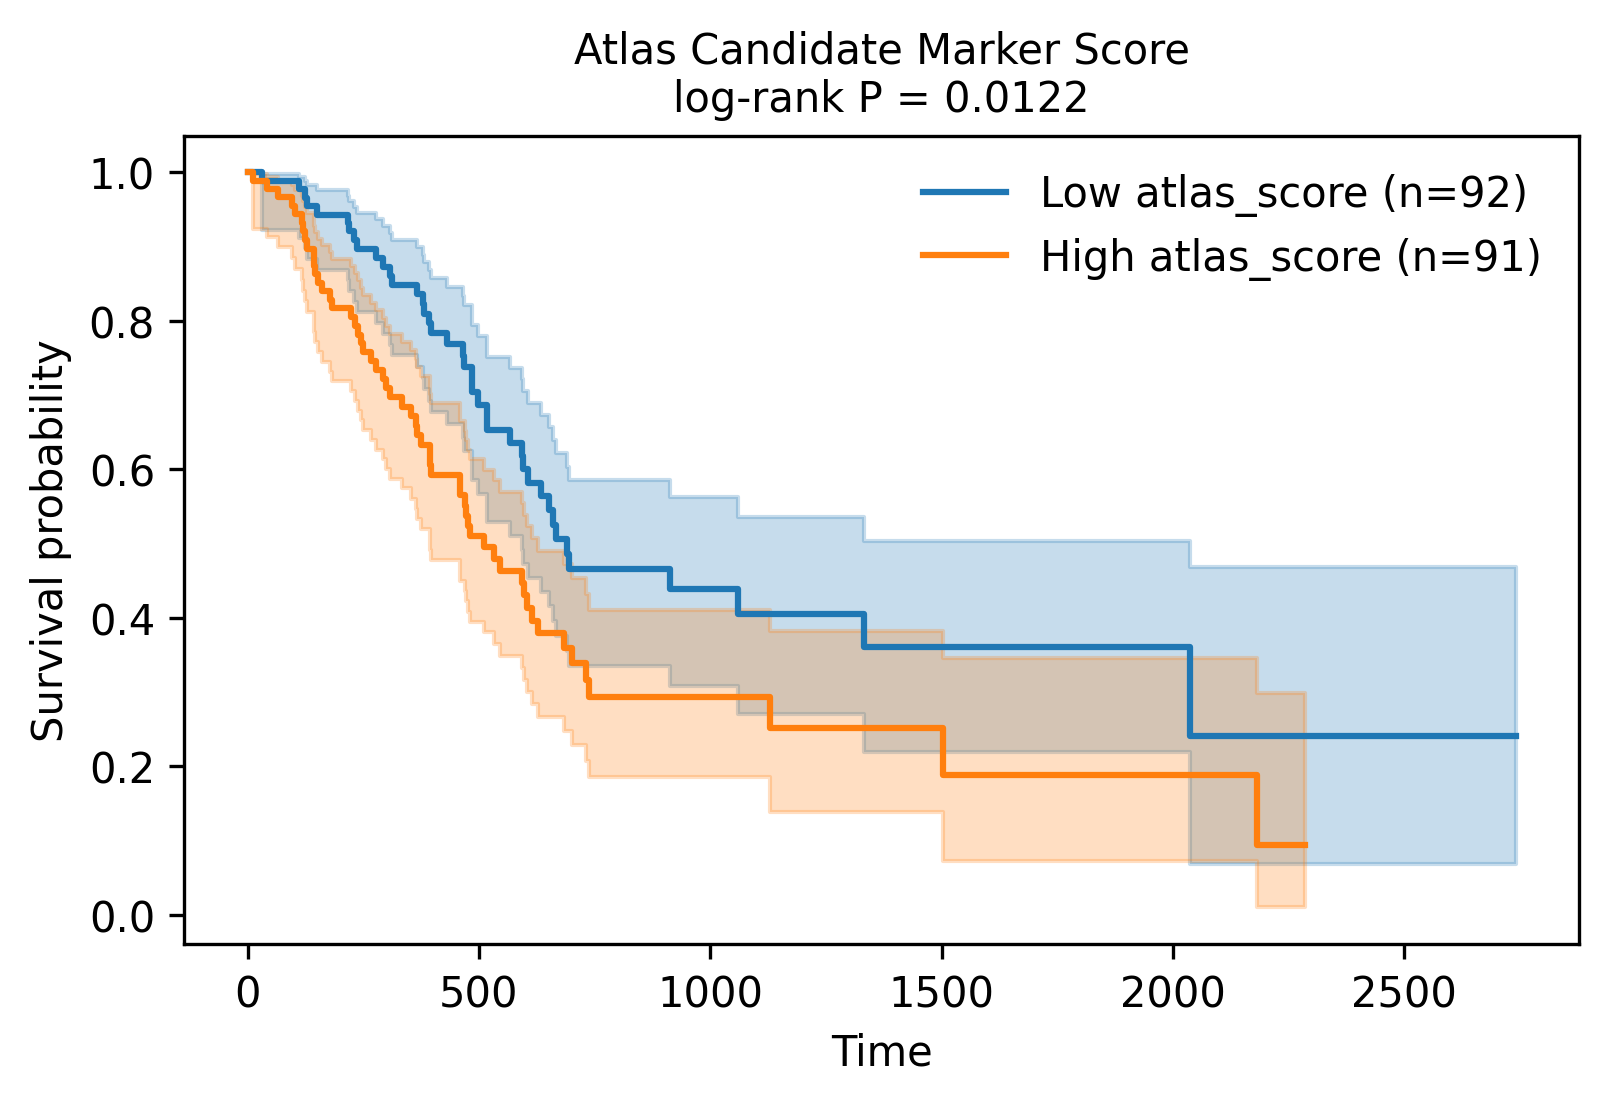

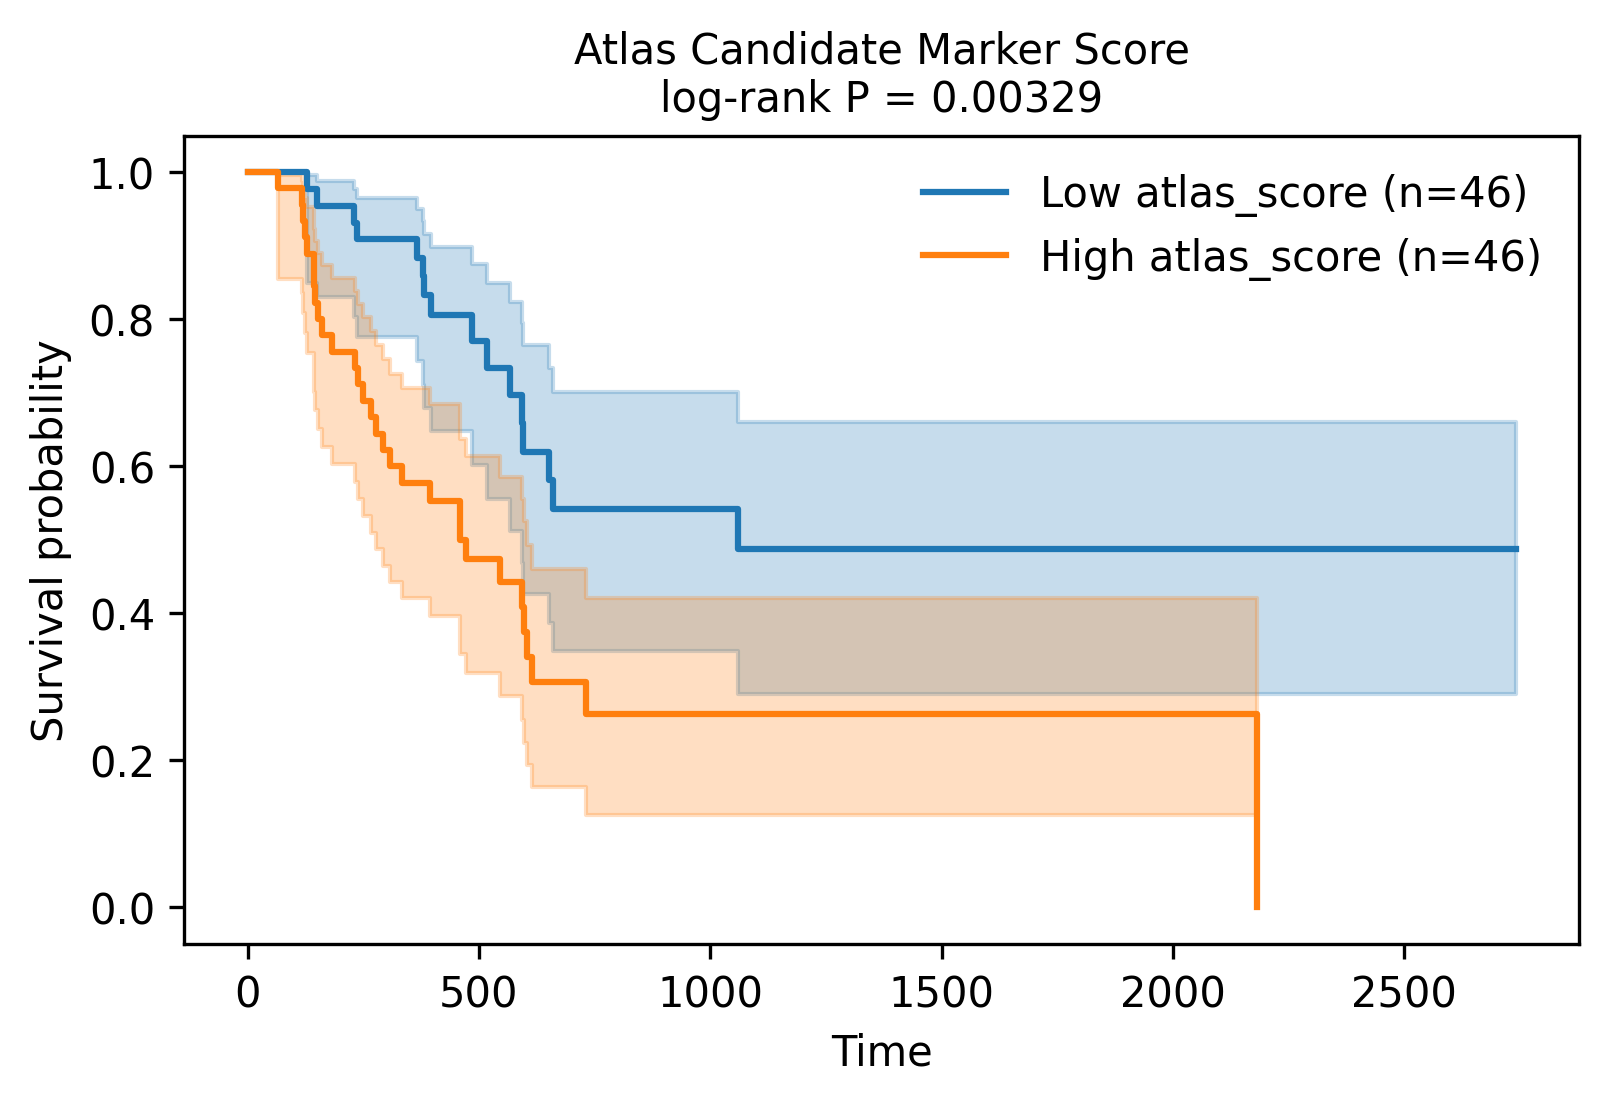

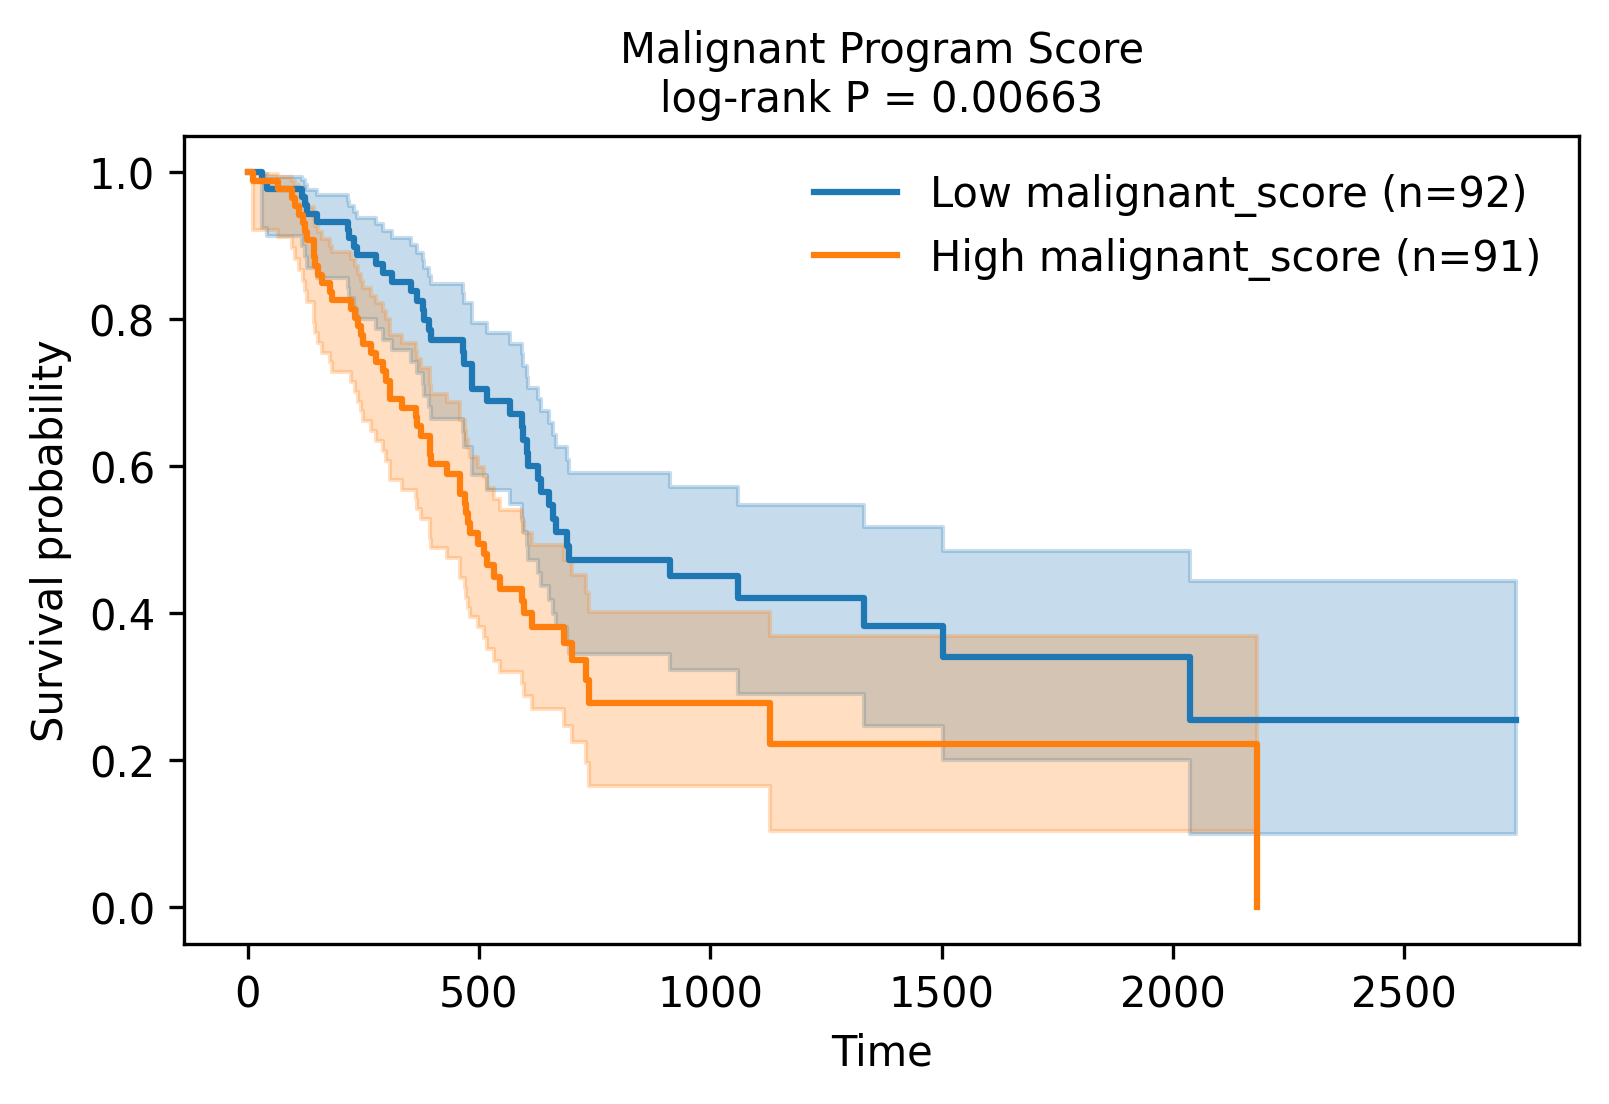

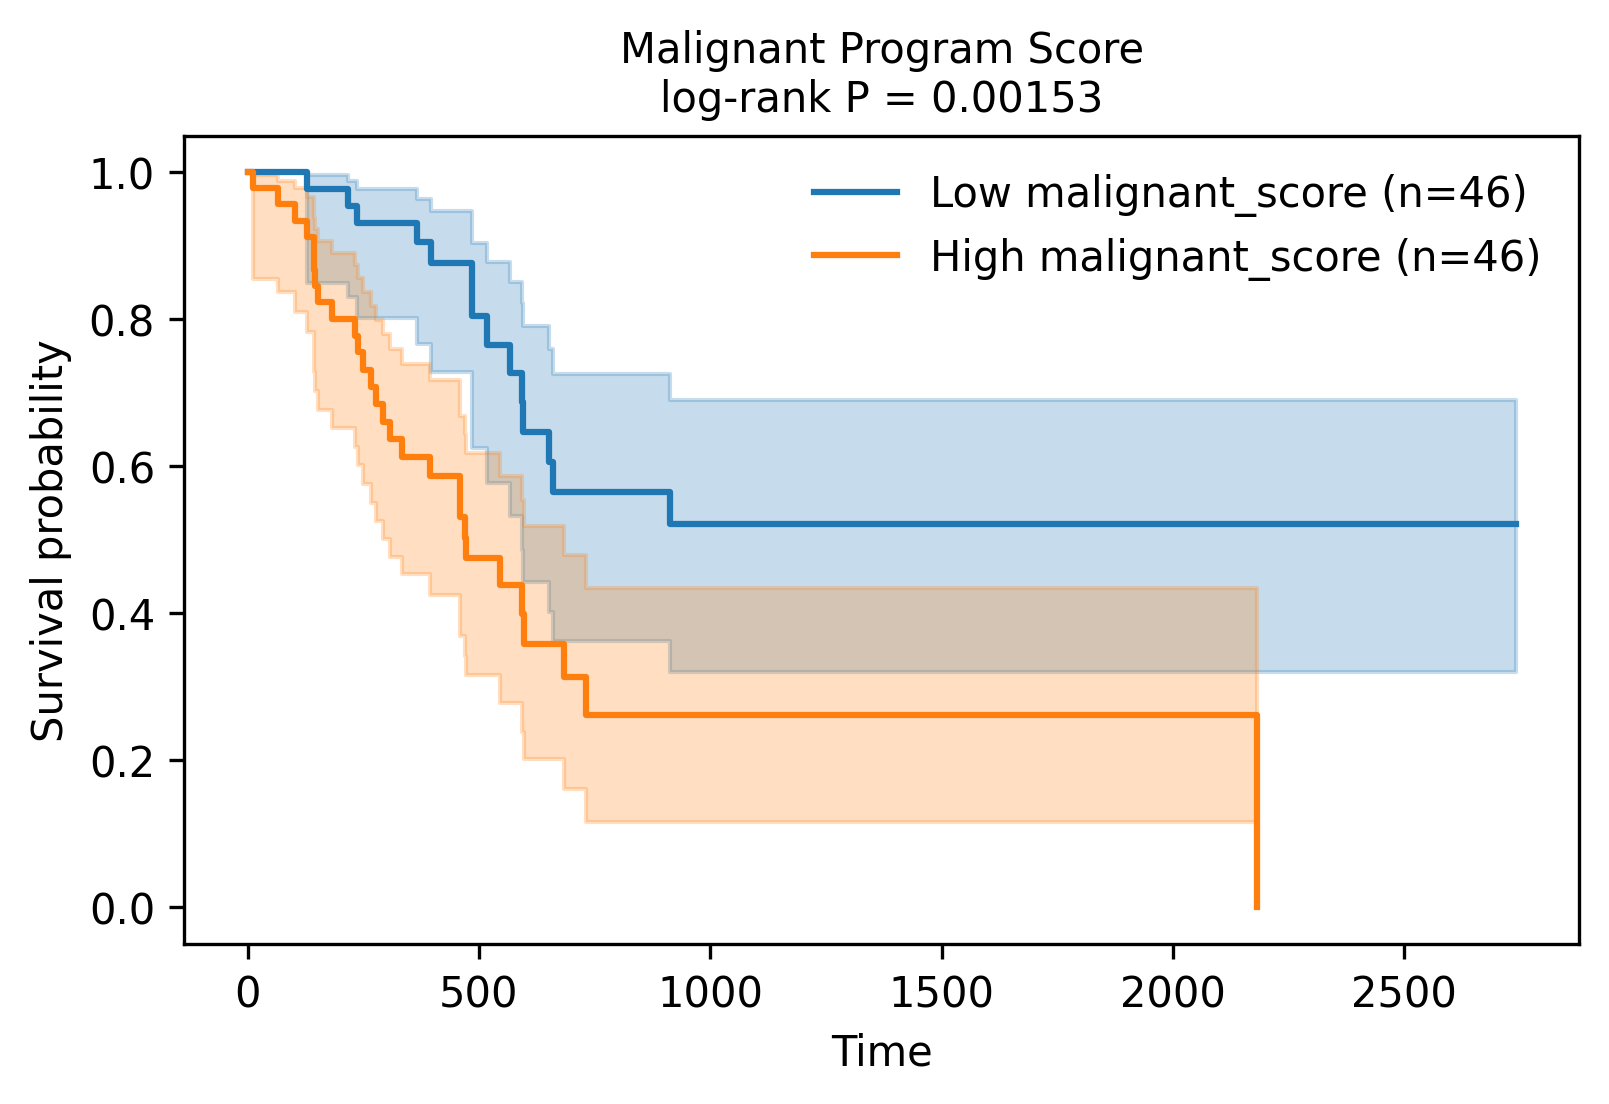

np.float64(0.001527851581820891)

In [60]:

# -----------------------------
# 6. KM plotting helper
# -----------------------------

def plot_km(df, score_col, title, split="median", fname=None):
    tmp = df[["time", "event", score_col]].dropna().copy()

    if split == "median":
        low_cut = high_cut = tmp[score_col].median()
        tmp["group"] = np.where(tmp[score_col] > high_cut, "High", "Low")

    elif split == "quartile":
        low_cut = tmp[score_col].quantile(0.25)
        high_cut = tmp[score_col].quantile(0.75)

        tmp = tmp[
            (tmp[score_col] <= low_cut) |
            (tmp[score_col] >= high_cut)
        ].copy()

        tmp["group"] = np.where(tmp[score_col] >= high_cut, "High", "Low")

    else:
        raise ValueError("split must be 'median' or 'quartile'")

    high = tmp["group"] == "High"
    low = tmp["group"] == "Low"

    lr = logrank_test(
        tmp.loc[high, "time"],
        tmp.loc[low, "time"],
        event_observed_A=tmp.loc[high, "event"],
        event_observed_B=tmp.loc[low, "event"]
    )

    kmf = KaplanMeierFitter()
    fig, ax = plt.subplots(figsize=(6, 3.5), dpi=300)

    for group in ["Low", "High"]:
        mask = tmp["group"] == group

        kmf.fit(
            durations=tmp.loc[mask, "time"],
            event_observed=tmp.loc[mask, "event"],
            label=f"{group} {score_col} (n={mask.sum()})"
        )

        kmf.plot_survival_function(ax=ax, ci_show=True)

    ax.set_title(f"{title}\nlog-rank P = {lr.p_value:.3g}", fontsize=10)
    ax.set_xlabel("Time")
    ax.set_ylabel("Survival probability")
    ax.legend(frameon=False)

    if fname:
        fig.savefig(fname, bbox_inches="tight", dpi=300)

    plt.show()

    return lr.p_value

# -----------------------------
# 7. KM plots for program scores
# -----------------------------

plot_km(
    df,
    "atlas_score",
    "Atlas Candidate Marker Score",
    split="median",
    fname="KM_atlas_score_median.svg"
)

plot_km(
    df,
    "atlas_score",
    "Atlas Candidate Marker Score",
    split="quartile",
    fname="KM_atlas_score_quartile.svg"
)

plot_km(
    df,
    "malignant_score",
    "Malignant Program Score",
    split="median",
    fname="KM_malignant_score_median.svg"
)

plot_km(
    df,
    "malignant_score",
    "Malignant Program Score",
    split="quartile",
    fname="KM_malignant_score_quartile.svg"
)


In [61]:

# -----------------------------
# 8. Per-gene Cox models
# -----------------------------

gene_results = []

for gene in malignant_genes:
    cph, cox_df = run_cox(df, [gene])

    row = cph.summary.loc[gene]

    gene_results.append({
        "gene": gene,
        "coef": row["coef"],
        "HR": row["exp(coef)"],
        "HR_lower": row["exp(coef) lower 95%"],
        "HR_upper": row["exp(coef) upper 95%"],
        "p": row["p"],
        "n": cox_df.shape[0],
        "is_atlas_gene": gene in atlas_genes,
        "c_index": cph.concordance_index_,
    })

gene_results = pd.DataFrame(gene_results)

gene_results["FDR"] = multipletests(
    gene_results["p"],
    method="fdr_bh"
)[1]

gene_results = gene_results.sort_values("FDR")

display(gene_results)

gene_results.to_csv("malignant_gene_cox_results.csv", index=False)


,gene,coef,HR,HR_lower,HR_upper,p,n,is_atlas_gene,c_index,FDR
3,PSCA,0.114711,1.121550,1.054047,1.193375,0.000292,183,False,0.5,0.001170
5,GPRC5A,0.184620,1.202761,1.088797,1.328654,0.000278,183,False,0.5,0.001170
10,AHNAK2,0.244938,1.277543,1.128071,1.446820,0.000114,183,True,0.5,0.001170
2,MSLN,0.130784,1.139722,1.058450,1.227234,0.000530,183,False,0.5,0.001579
7,SEMA3C,0.229615,1.258115,1.100188,1.438712,0.000793,183,True,0.5,0.001579
6,KRT6A,0.113015,1.119649,1.049002,1.195054,0.000677,183,False,0.5,0.001579
0,S100P,0.117915,1.125149,1.049347,1.206426,0.000921,183,False,0.5,0.001579
1,TMPRSS4,0.166740,1.181447,1.064005,1.311853,0.001800,183,False,0.5,0.002700
8,TNS4,0.134032,1.143430,1.047891,1.247680,0.002606,183,True,0.5,0.003475
9,CLIC3,0.135474,1.145079,1.042138,1.258189,0.004821,183,True,0.5,0.005785


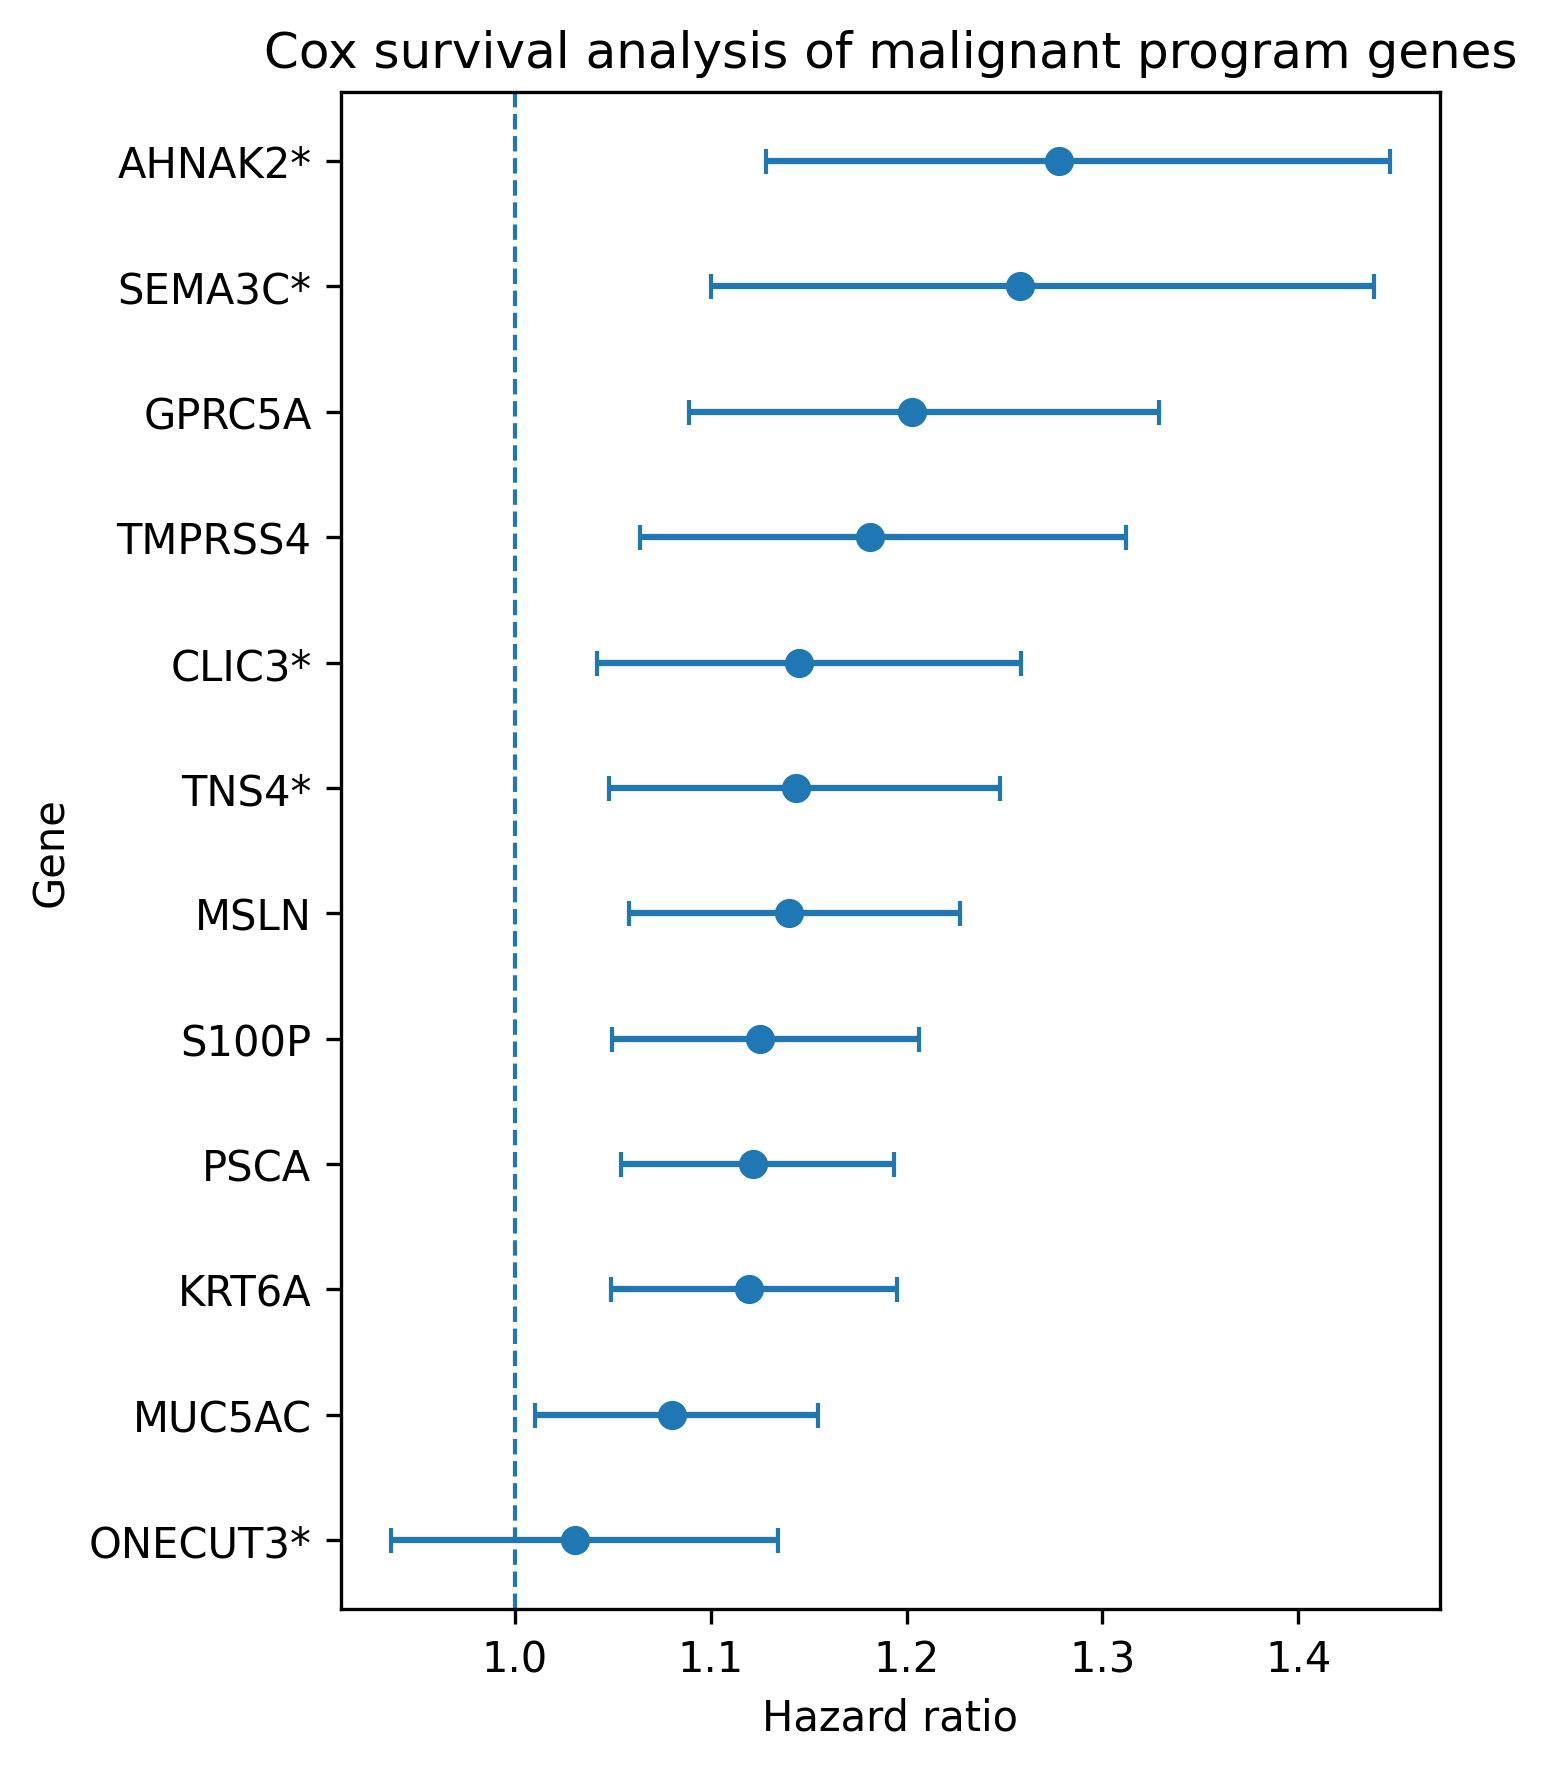

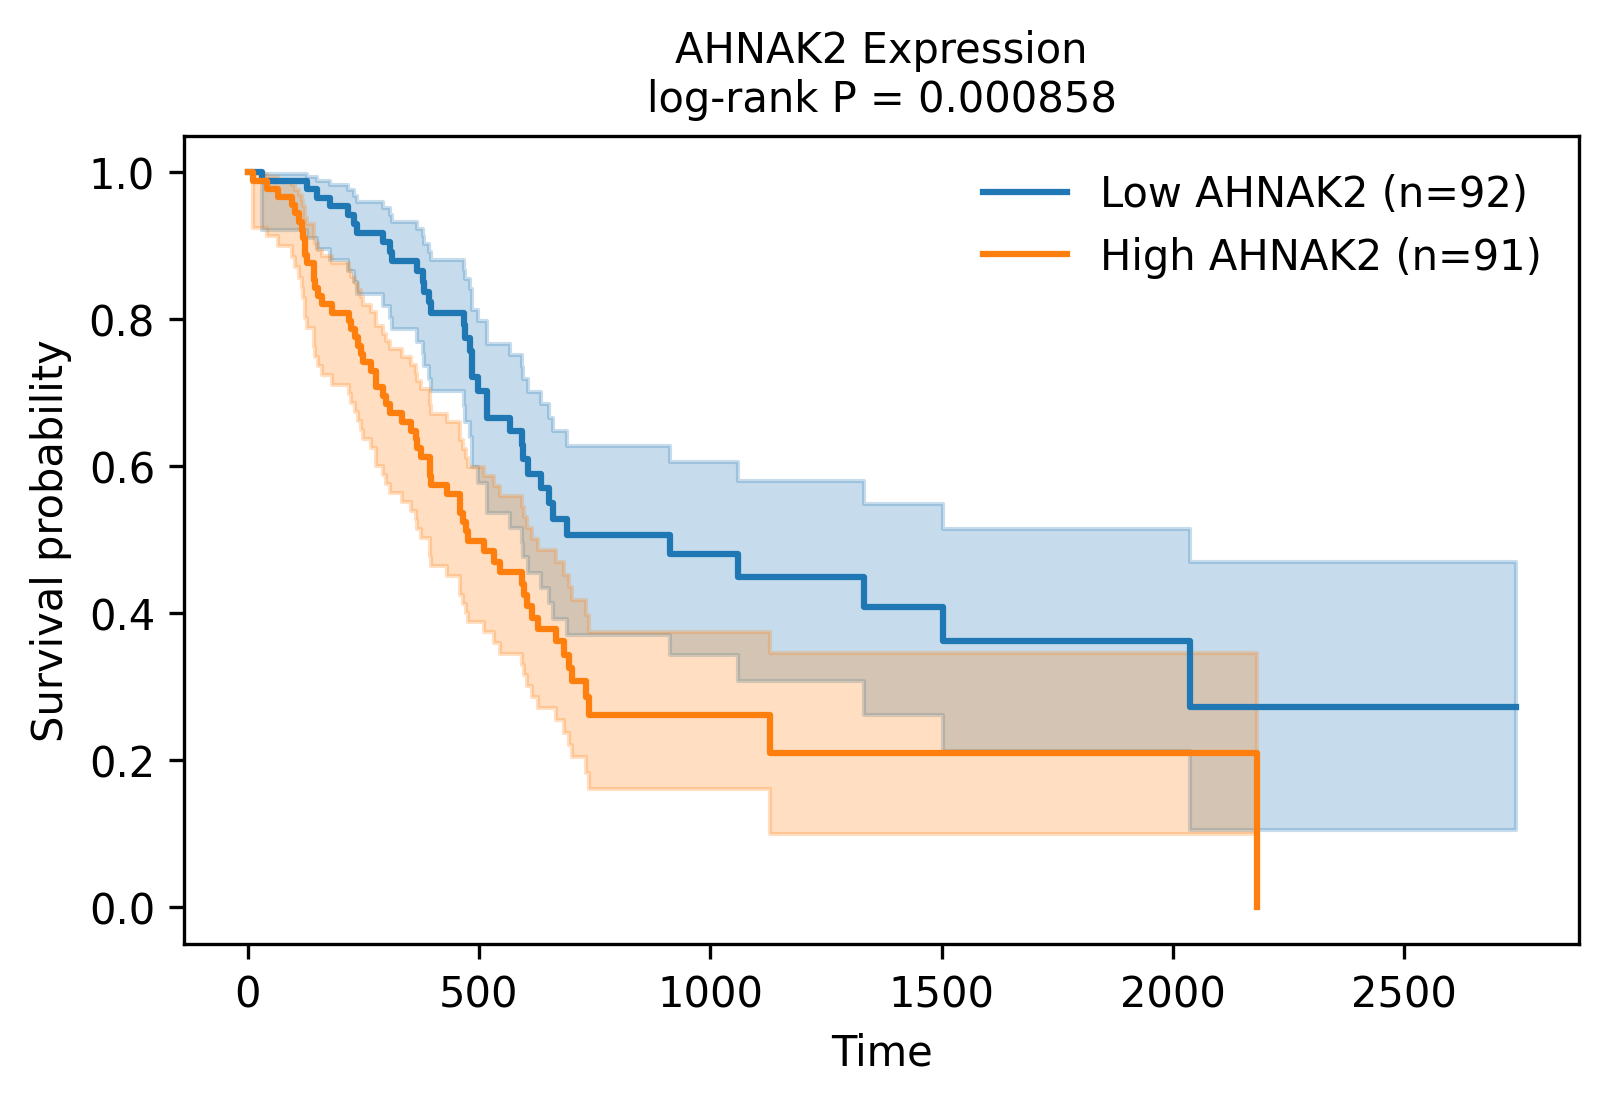

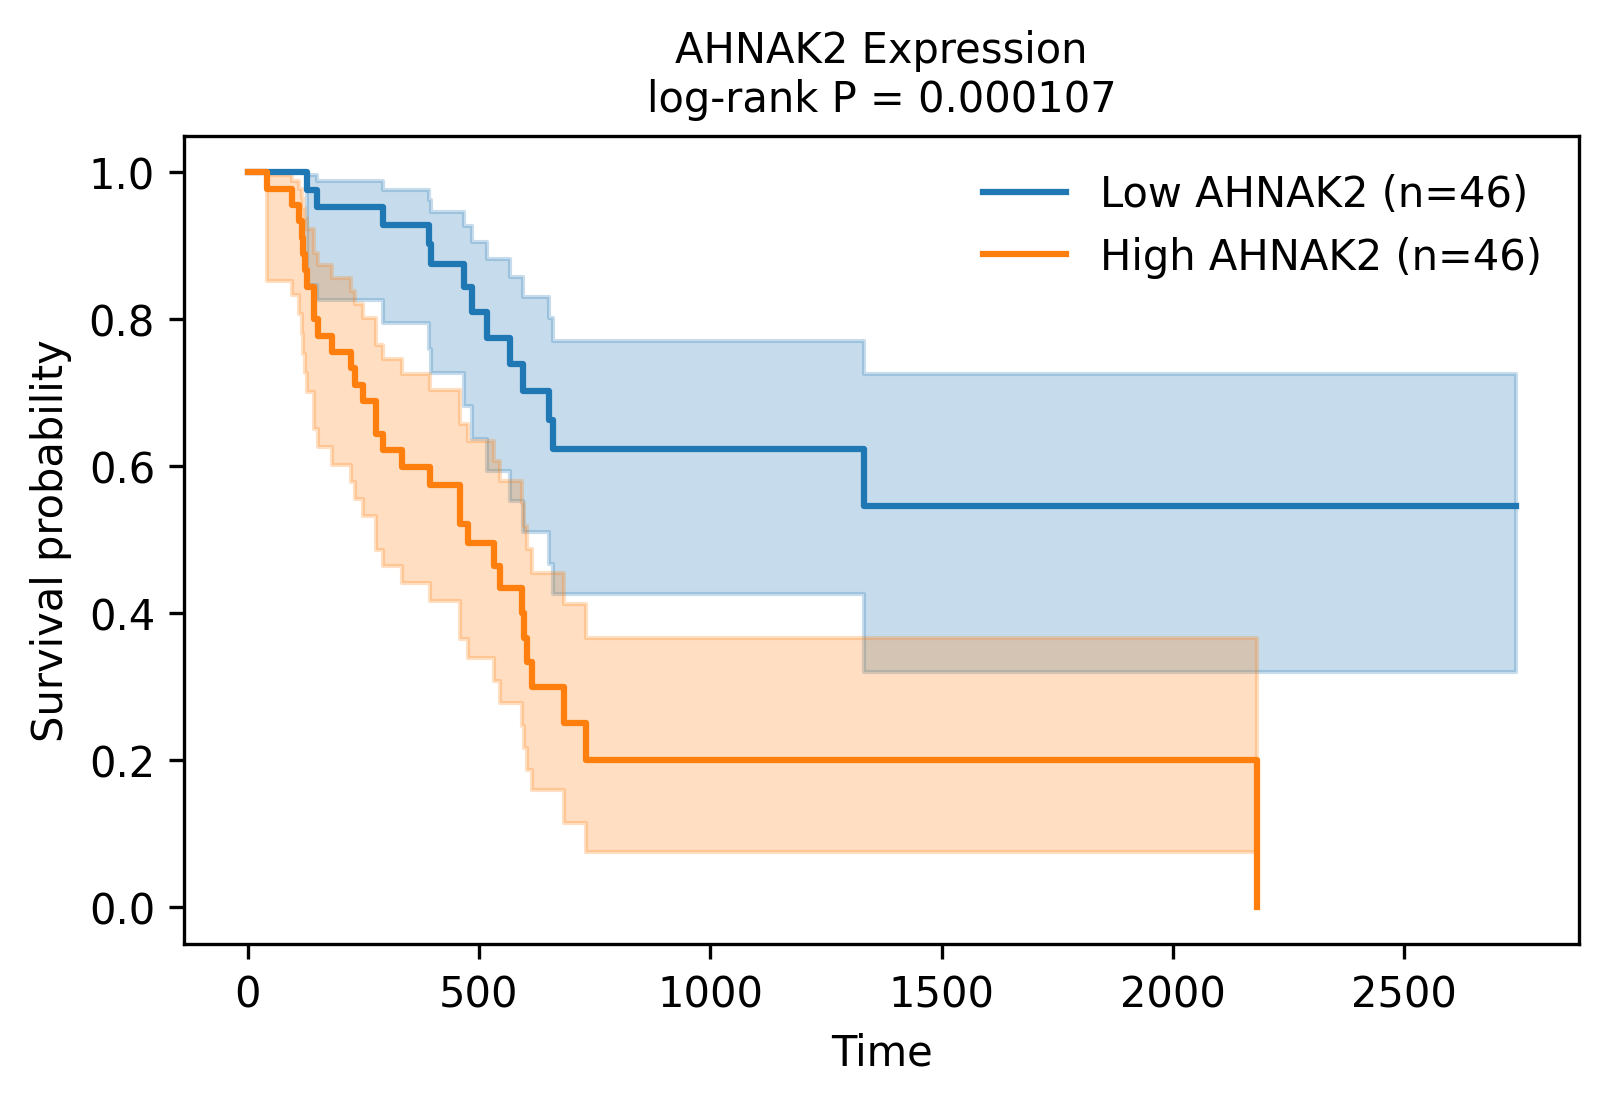

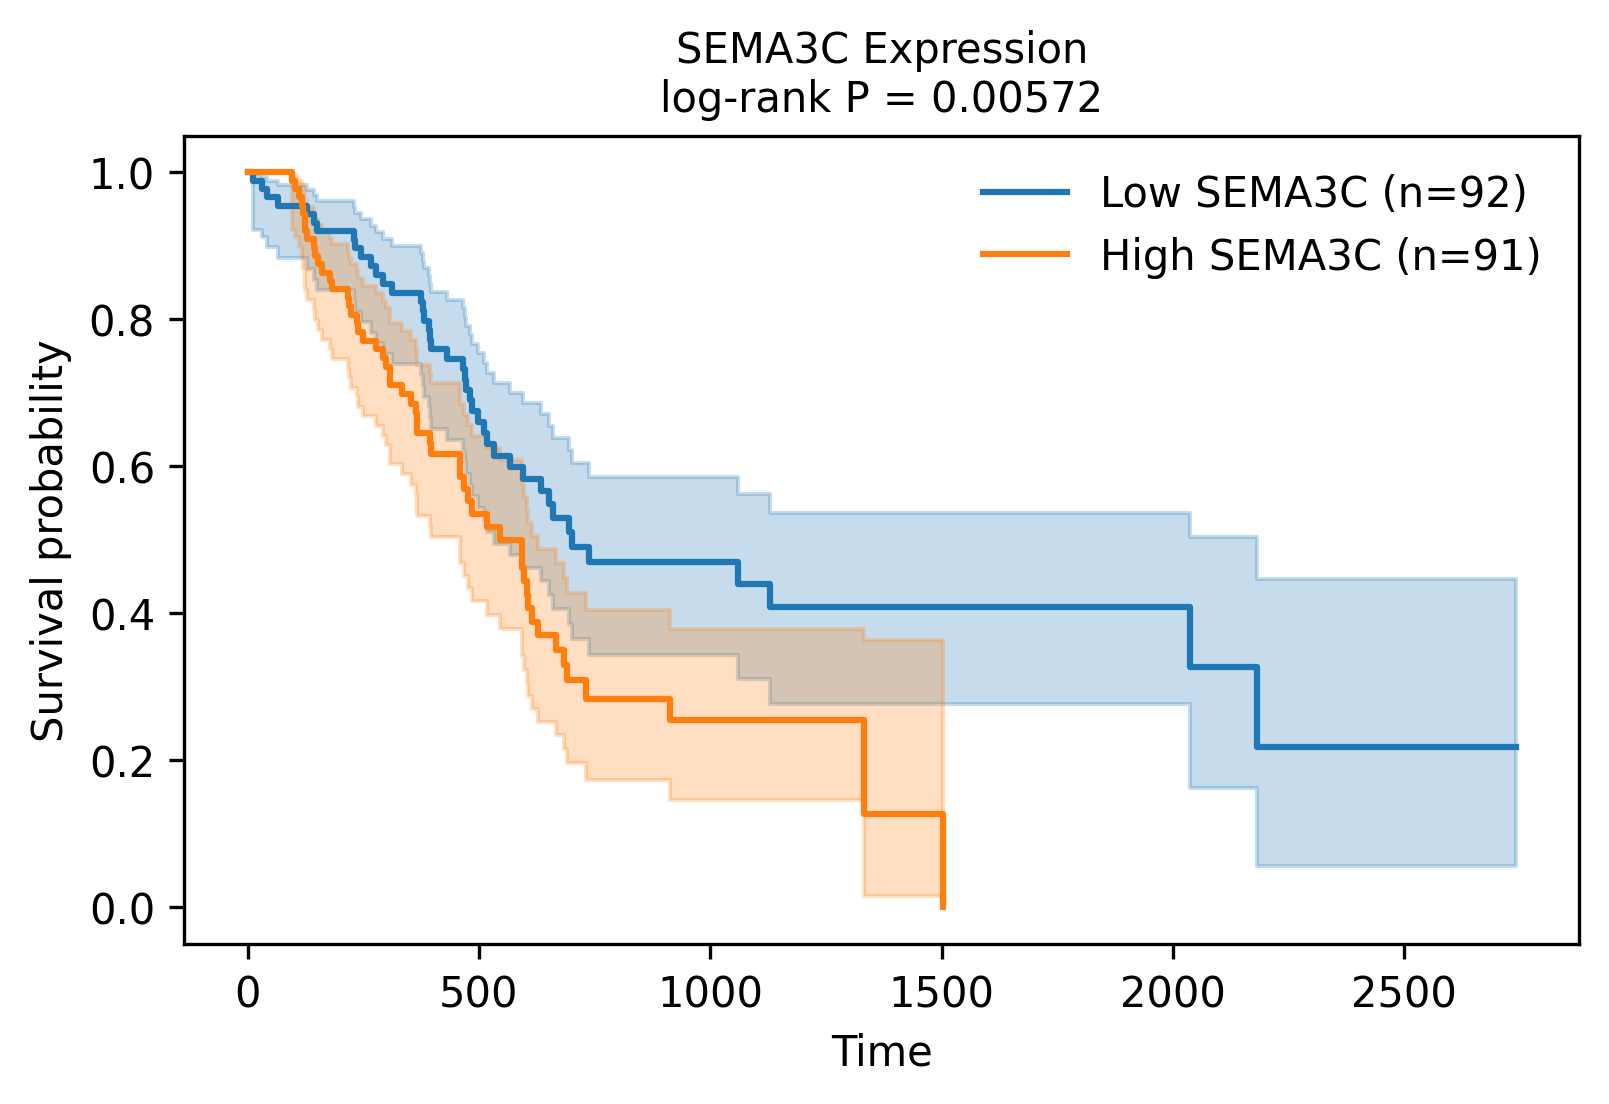

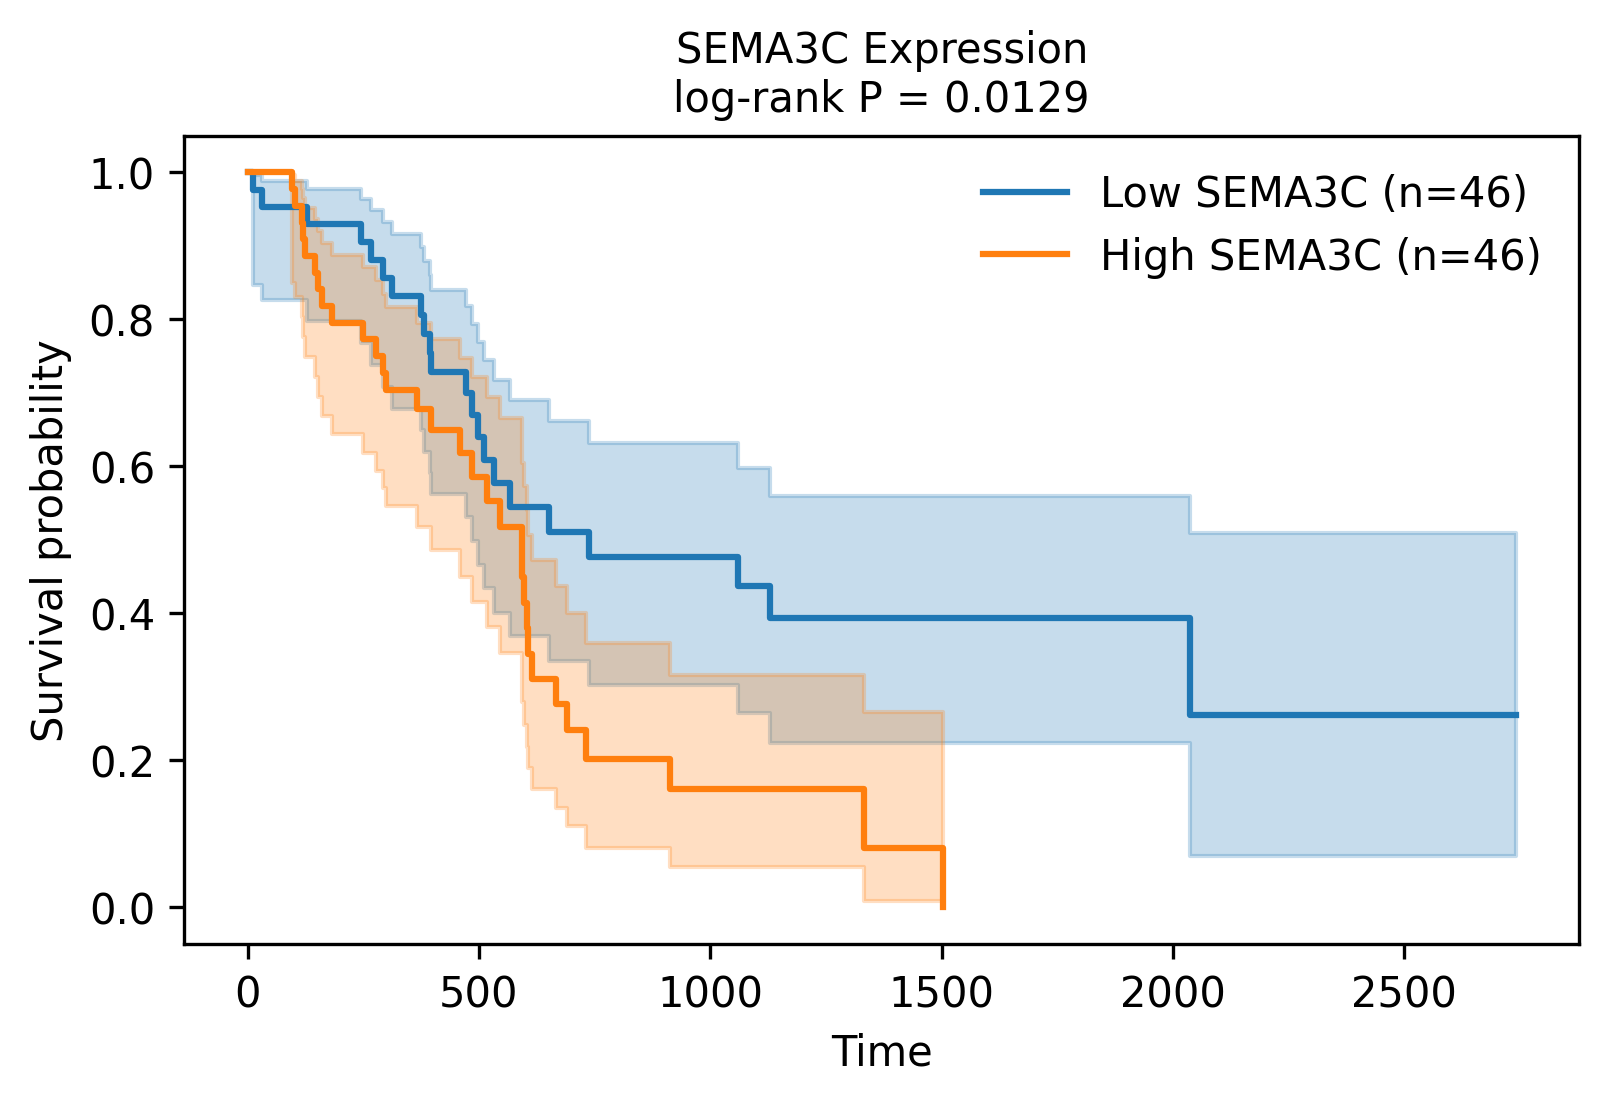

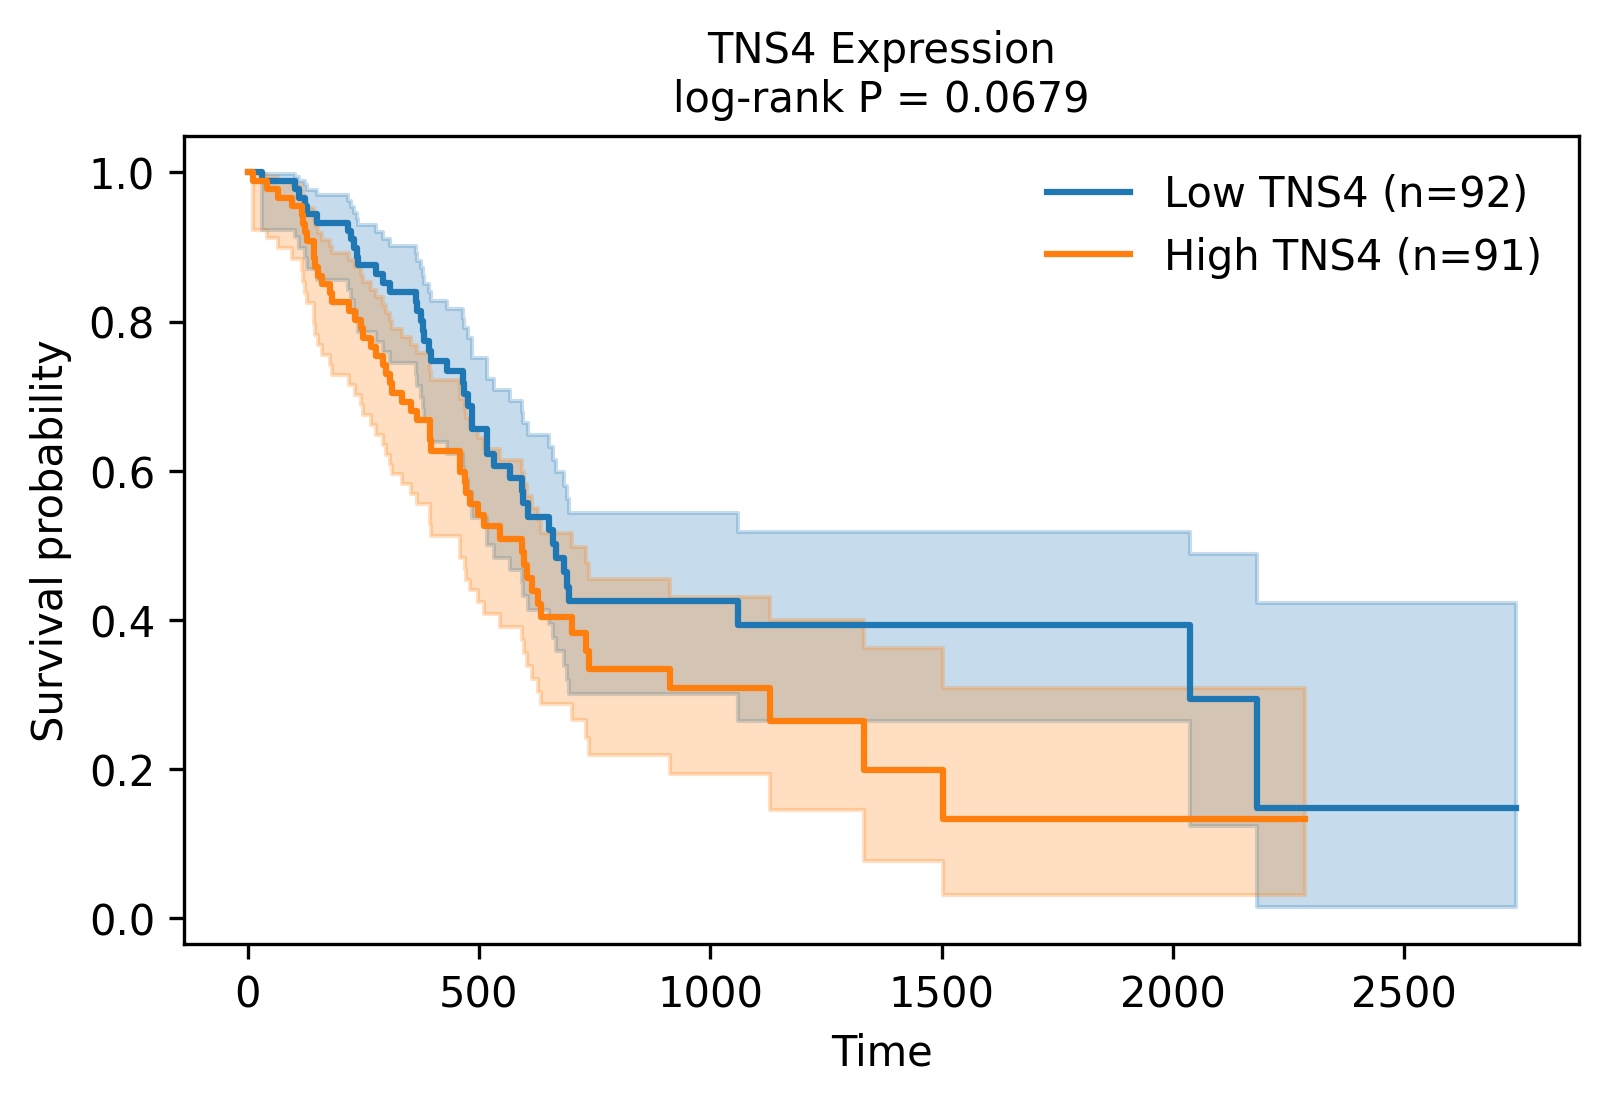

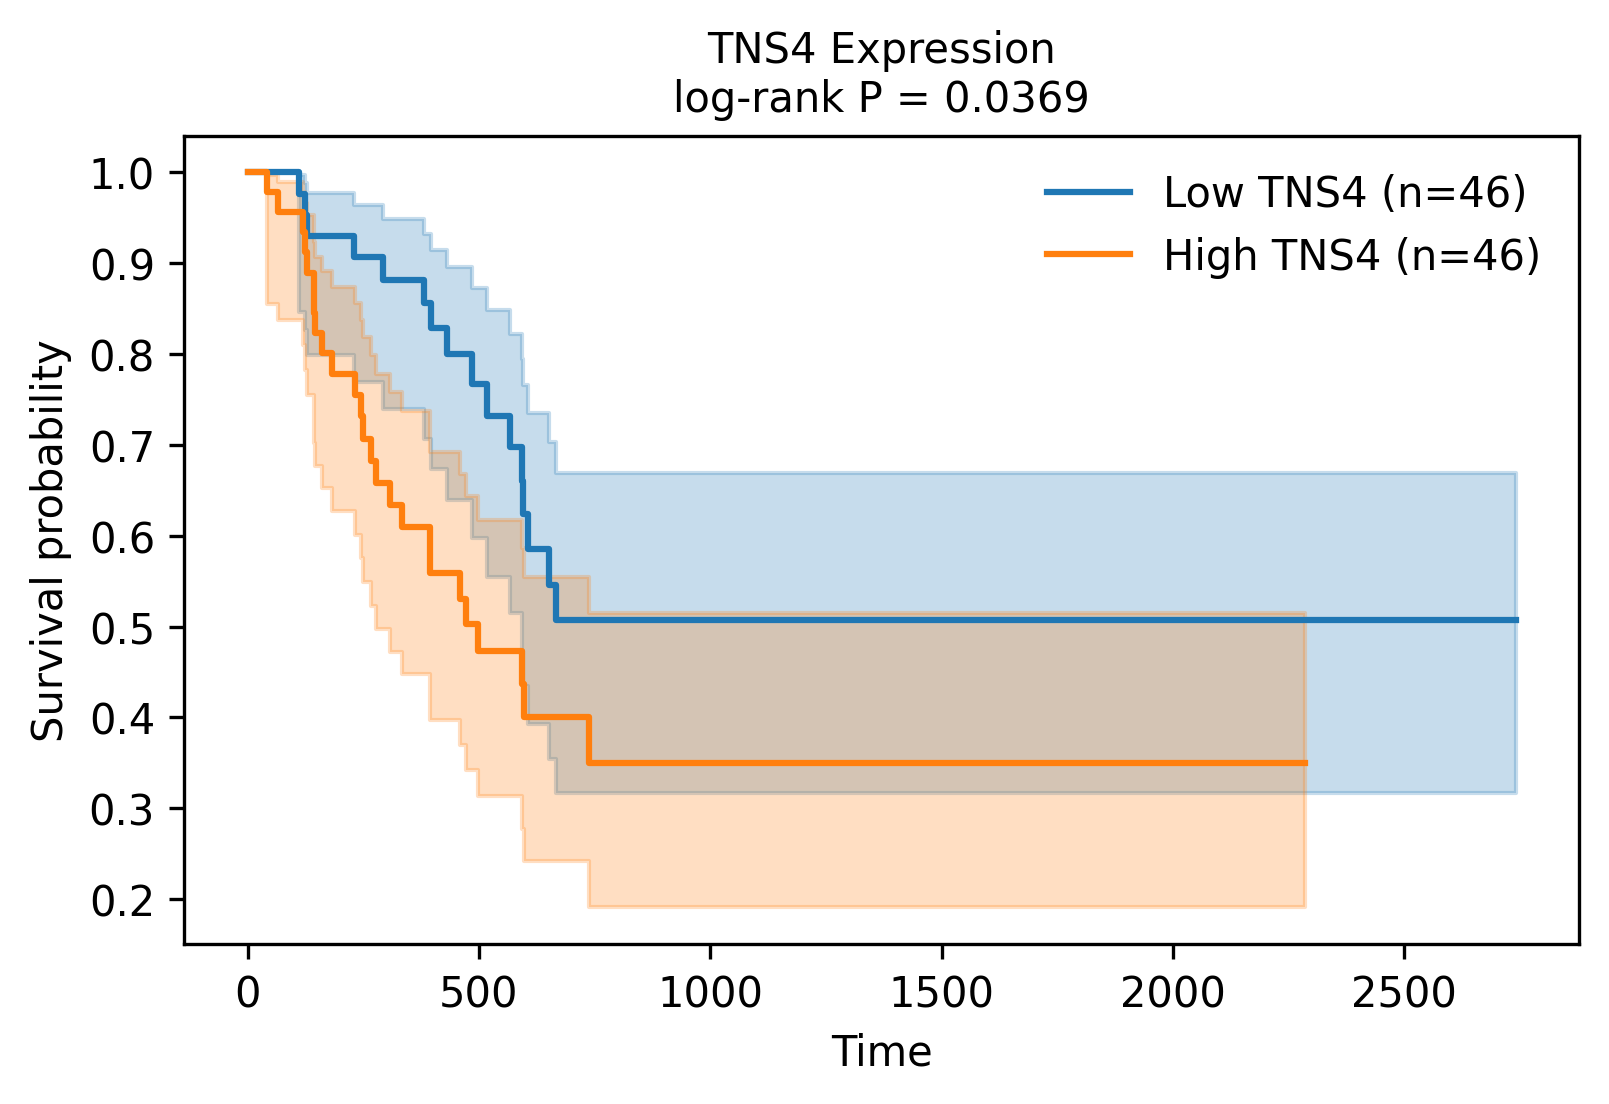

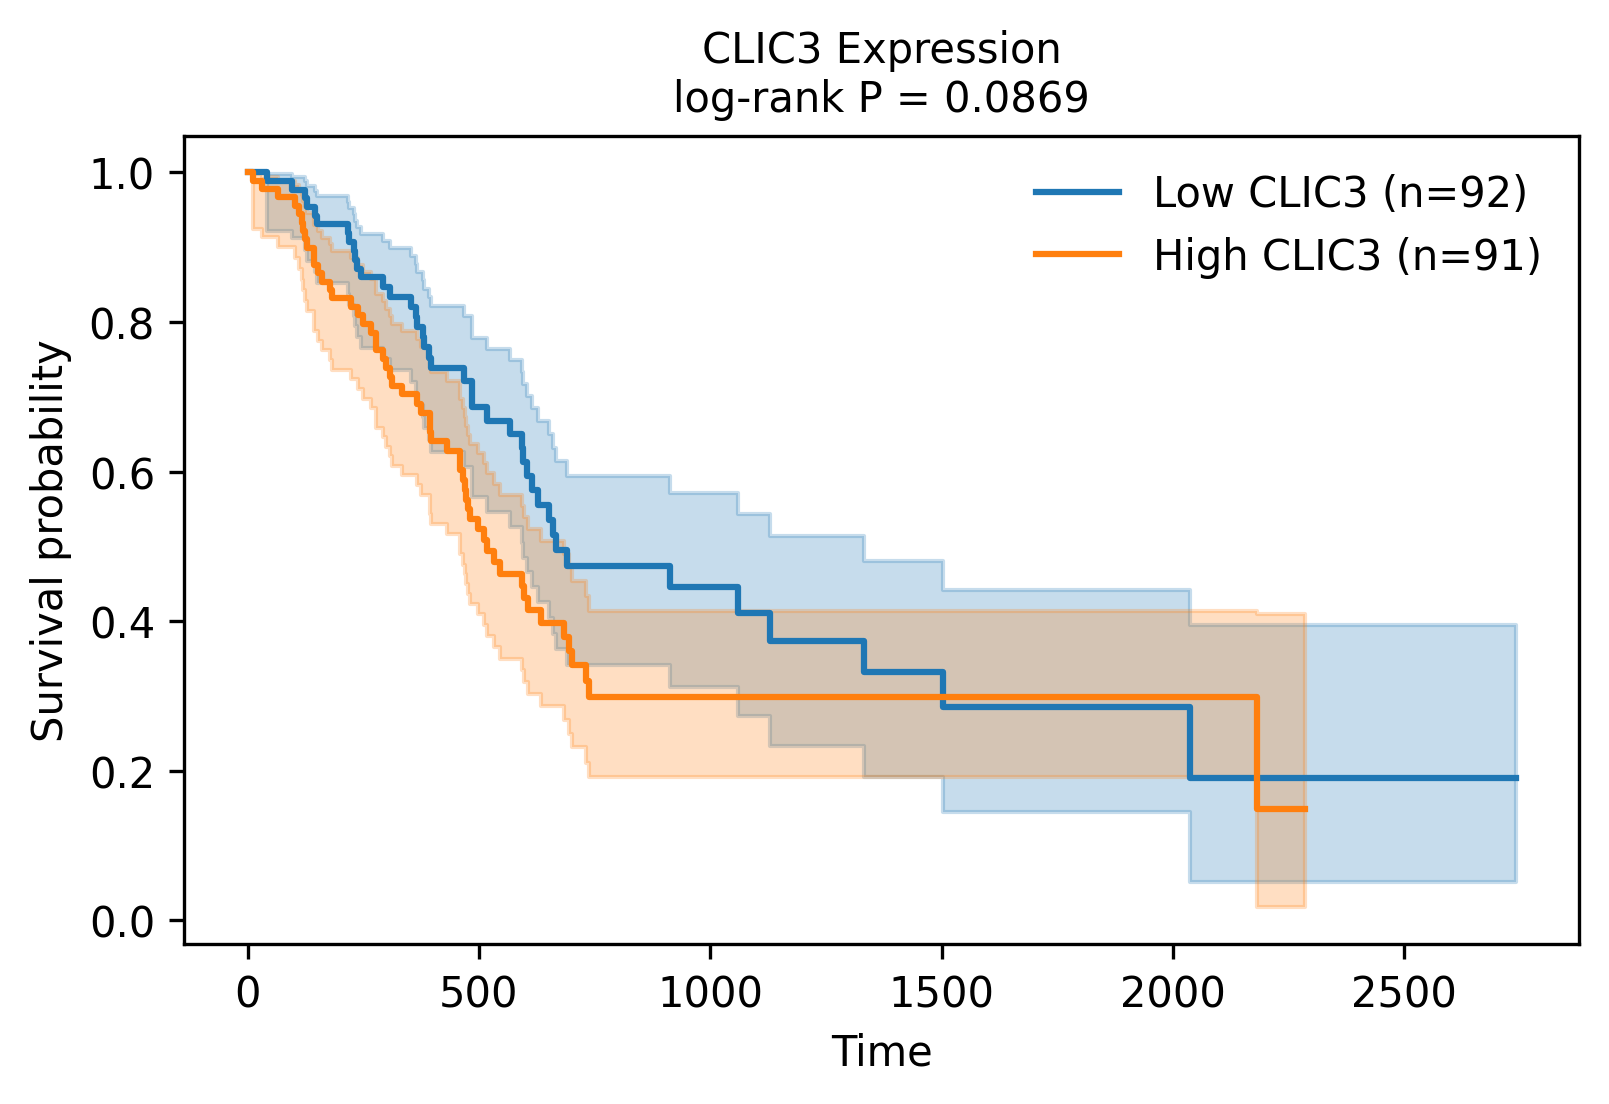

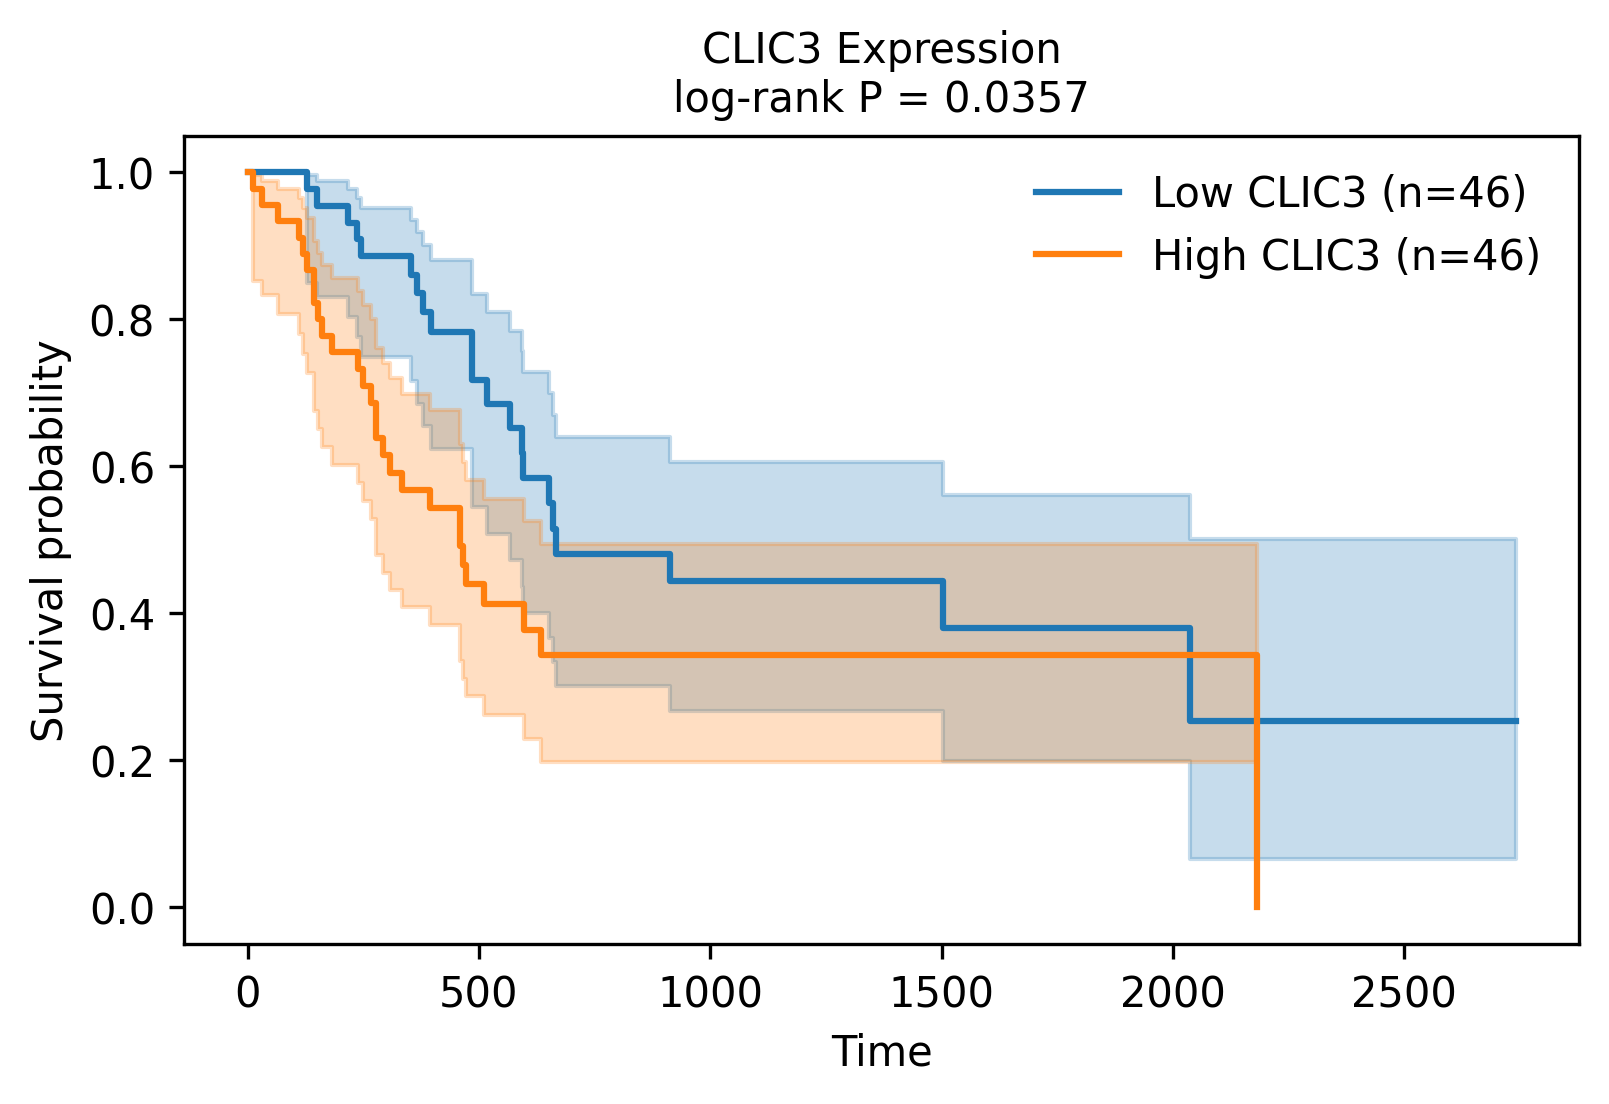

In [63]:

# -----------------------------
# 9. Forest plot for individual genes
# -----------------------------

res = gene_results.sort_values("HR")

fig, ax = plt.subplots(figsize=(5, 6), dpi=300)

ax.errorbar(
    res["HR"],
    np.arange(len(res)),
    xerr=[
        res["HR"] - res["HR_lower"],
        res["HR_upper"] - res["HR"]
    ],
    fmt="o",
    capsize=3
)

ax.axvline(1, linestyle="--", linewidth=1)

labels = [
    f"{gene}*" if is_atlas else gene
    for gene, is_atlas in zip(res["gene"], res["is_atlas_gene"])
]

ax.set_yticks(np.arange(len(res)))
ax.set_yticklabels(labels)

ax.set_xlabel("Hazard ratio")
ax.set_ylabel("Gene")
ax.set_title("Cox survival analysis of malignant program genes")

plt.tight_layout()
fig.savefig("malignant_gene_forest_plot.svg", bbox_inches="tight", dpi=300)
plt.show()

# -----------------------------
# 10. Individual KM plots for selected atlas genes
# -----------------------------

selected_genes_for_km = [
    "AHNAK2",
    "SEMA3C",
    "TNS4",
    "CLIC3",
]

selected_genes_for_km = [
    g for g in selected_genes_for_km
    if g in df.columns
]

for gene in selected_genes_for_km:
    plot_km(
        df,
        gene,
        f"{gene} Expression",
        split="median",
        fname=f"KM_{gene}_median.svg"
    )

    plot_km(
        df,
        gene,
        f"{gene} Expression",
        split="quartile",
        fname=f"KM_{gene}_quartile.svg"
    )

# # -----------------------------
# # 11. Optional proportional hazards checks
# # -----------------------------

# cph_malignant, cox_df_malignant = run_cox(df, ["malignant_score"])

# cph_malignant.check_assumptions(
#     cox_df_malignant,
#     p_value_threshold=0.05,
#     show_plots=True
# )